In [1]:
import requests
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import time
from datetime import datetime, timedelta
import calendar
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np
import re

## Functions

In [2]:
def get_mastodon_keyword_data(date_from, date_to):
    api_url = f"http://localhost:9090/keywordmastodon/{date_from}/{date_to}"

    response = requests.get(api_url)

    if response.status_code == 200:
        data = response.json().get('Data', [])
        if data:
            return data
        else:
            print("No data returned by the API.")
            return None
    else:
        print(f"Error: {response.status_code} - {response.text}")
        return None

In [38]:
def get_mastodon_keyword_sentiment(date_from, date_to, keyword):
    api_url = f"http://localhost:9090/mastondonkeywordsentiment/{date_from}/{date_to}/{keyword}"

    response = requests.get(api_url)

    if response.status_code == 200:
        data = response.json().get('Data', [])
        if data:
            return data
        else:
            print("No data returned by the API.")
            return None
    else:
        print(f"Error: {response.status_code} - {response.text}")
        return None

In [37]:
def get_mastodon_keyword_sentiment_error(date_from, date_to, keyword):
    api_url = f"http://localhost:9090/mastondonkeywordsentiment/{date_from}/{date_to}/{keyword}"

    response = requests.get(api_url)

    if response.status_code == 200:
        data = response.json().get("Data", [])
        if data:
            return data
        else:
            return {"error": "No data returned"}  # ← return a dict instead of just printing
    else:
        return f"Error: {response.status_code} - {response.text}"  # ← return the error string

In [4]:
def get_offender_rate():
    api_url = "http://localhost:9090/offender/total/Total/rate"

    response = requests.get(api_url)

    if response.status_code == 200:
        data = response.json().get('Data', [])
        if data:
            return data
        else:
            print("No data returned by the API.")
            return None
    else:
        print(f"Error: {response.status_code} - {response.text}")
        return None

In [5]:
def get_victim_rate():
    api_url = "http://localhost:9090/victim/total/rate"
        
    response = requests.get(api_url)

    if response.status_code == 200:
        data = response.json().get('Data', [])
        if data:
            return data
        else:
            print("No data returned by the API.")
            return None
    else:
        print(f"Error: {response.status_code} - {response.text}")
        return None

In [6]:
def get_dwelling():
    # API and Timeframe
    BASE_URL = "http://localhost:9090/housetransfer"
    start_year = 2010
    end_year = 2024
    quarters = [3, 6, 9, 12]

    # Store national stats per quarter
    national_stats = []

    for year in range(start_year, end_year + 1):
        for month in quarters:
            url = f"{BASE_URL}/{year}/{month}/{year}/{month}"
            try:
                response = requests.get(url)
                if response.status_code == 200:
                    data = response.json().get("Data", [])

                    # Aggregates
                    total_est_house = 0
                    total_att_dwell = 0
                    weighted_est_sum = 0
                    weighted_att_sum = 0

                    for region in data:
                        # Handle Established Houses
                        est_price = region.get("Median_Est_House")
                        est_count = region.get("Num_Est_House")
                        if est_price and est_count:
                            weighted_est_sum += est_price * est_count
                            total_est_house += est_count

                        # Handle Attached Dwellings
                        att_price = region.get("Median_Att_Dwell")
                        att_count = region.get("Num_Att_Dwell")
                        if att_price and att_count:
                            weighted_att_sum += att_price * att_count
                            total_att_dwell += att_count

                    # Compute weighted averages
                    avg_est_price = weighted_est_sum / total_est_house if total_est_house > 0 else None
                    avg_att_price = weighted_att_sum / total_att_dwell if total_att_dwell > 0 else None

                    # Store results
                    national_stats.append({
                        "Year": year,
                        "Month": month,
                        "Total_Est_House_Transfers": total_est_house,
                        "Total_Att_Dwell_Transfers": total_att_dwell,
                        "Weighted_Median_Est_House": avg_est_price,
                        "Weighted_Median_Att_Dwell": avg_att_price
                    })
                else:
                    print(f"API error: {response.status_code} for {year}-{month:02}")
            except Exception as e:
                print(f"Request failed for {year}-{month:02}: {e}")

    # Convert to DataFrame
    df_national = pd.DataFrame(national_stats)
    df_national.sort_values(by=["Year", "Month"], inplace=True)
    return df_national

In [7]:
def try_chunked_avg(start_date_str, end_date_str, keyword, chunk_days=5):
    start = datetime.strptime(start_date_str, "%Y-%m-%d")
    end = datetime.strptime(end_date_str, "%Y-%m-%d")
    total = 0
    count = 0

    while start <= end:
        chunk_end = min(start + timedelta(days=chunk_days - 1), end)
        chunk_start_str = start.strftime("%Y-%m-%d")
        chunk_end_str = chunk_end.strftime("%Y-%m-%d")

        try:
            res = get_mastodon_keyword_sentiment(chunk_start_str, chunk_end_str, keyword)
            if res and 'avg_sentiment' in res and res['avg_sentiment'] is not None:
                total += res['avg_sentiment']
                count += 1
        except Exception as e:
            print(f"    Chunk error {chunk_start_str} to {chunk_end_str}: {e}")
        
        start = chunk_end + timedelta(days=1)
        time.sleep(1)

    return total / count if count > 0 else None

In [8]:
def get_monthly_avg(year):
    total = 0
    count = 0

    for m in range(7, 13):  # July–December
        start = f"{year}-{m:02d}-01"
        _, last_day = calendar.monthrange(year, m)
        end = f"{year}-{m:02d}-{last_day}"
        try:
            res = get_mastodon_keyword_sentiment(start, end, keyword)
            if res and 'avg_sentiment' in res and res['avg_sentiment'] is not None:
                avg = res['avg_sentiment']
            else:
                raise ValueError("Empty or invalid result")
        except Exception as e:
            print(f"  Monthly error {start} to {end}, trying finer chunks...")
            avg = try_chunked_avg(start, end, keyword)

        if avg is not None:
            total += avg
            count += 1
        time.sleep(1)

    for m in range(1, 7):  # January–June (next year)
        start = f"{year+1}-{m:02d}-01"
        _, last_day = calendar.monthrange(year+1, m)
        end = f"{year+1}-{m:02d}-{last_day}"
        try:
            res = get_mastodon_keyword_sentiment(start, end, keyword)
            if res and 'avg_sentiment' in res and res['avg_sentiment'] is not None:
                avg = res['avg_sentiment']
            else:
                raise ValueError("Empty or invalid result")
        except Exception as e:
            print(f"  Monthly error {start} to {end}, trying finer chunks...")
            avg = try_chunked_avg(start, end, keyword)

        if avg is not None:
            total += avg
            count += 1
        time.sleep(1)

    return total / count if count > 0 else None

In [ ]:
def fetch_sentiment_safe(start_date: str, end_date: str, keyword: str, min_days=1):
    """Attempt to fetch sentiment, fallback to shorter intervals if 500-like error."""
    try:
        response = get_mastodon_keyword_sentiment(start_date, end_date, keyword)

        # If it's a string and looks like a 500 error
        if isinstance(response, str) and "500" in response:
            raise Exception("500")

        # If it's a dict with error message
        if isinstance(response, dict) and (
            "error" in response and "500" in str(response["error"])
        ):
            raise Exception("500")

        # Normal case
        if isinstance(response, dict) and 'avg_sentiment' in response and response['avg_sentiment'] is not None:
            return [response['avg_sentiment']]

        return []  # empty or no valid result

    except Exception as e:
        # Force fallback only for 500 error or suspicious failure
        if "500" in str(e) or "error sending request" in str(e).lower():
            start_dt = datetime.strptime(start_date, "%Y-%m-%d")
            end_dt = datetime.strptime(end_date, "%Y-%m-%d")
            delta_days = (end_dt - start_dt).days

            if delta_days <= min_days:
                print(f"Window too small: {start_date} → {end_date}. Giving up.")
                return []

            # Split and recurse
            mid_dt = start_dt + timedelta(days=delta_days // 2)
            mid_date = mid_dt.strftime("%Y-%m-%d")

            print(f"Splitting: {start_date} → {mid_date} and {mid_date} → {end_date}")
            left = fetch_sentiment_safe(start_date, mid_date, keyword, min_days)
            right = fetch_sentiment_safe(mid_date, end_date, keyword, min_days)
            return left + right

        else:
            print(f"Error for {start_date} to {end_date}: {e}")
            return []

In [10]:
def get_quarterly_sentiment_robust(year, month, keyword):
    """Get sentiment for a quarter, fallback on failures."""
    start_date = f"{year}-{month:02}-01"
    if month == 12:
        end_date = f"{year + 1}-02-28"
    else:
        end_month = month + 2
        end_date = f"{year}-{end_month:02}-28"

    sentiments = fetch_sentiment_safe(start_date, end_date, keyword)
    sentiments = [s for s in sentiments if s is not None]  # <<< filter None

    if sentiments:
        return sum(sentiments) / len(sentiments)
    return None


In [ ]:
def fetch_post_count_safe(start_date: str, end_date: str, min_days=1) -> int:
    """Recursive post count fetcher with 500-error fallback."""
    try:
        result = get_mastodon_keyword_sentiment_error(start_date, end_date, keyword=keyword)
        if isinstance(result, dict) and "count" in result:
            return result["count"]
        else:
            return 0
    except Exception as e:
        if "500" in str(e) or "error sending request" in str(e).lower():
            start_dt = datetime.strptime(start_date, "%Y-%m-%d")
            end_dt = datetime.strptime(end_date, "%Y-%m-%d")
            delta_days = (end_dt - start_dt).days

            if delta_days <= min_days:
                print(f"Window too small: {start_date} → {end_date}. Giving up.")
                return 0

            mid_dt = start_dt + timedelta(days=delta_days // 2)
            mid_str = mid_dt.strftime("%Y-%m-%d")

            print(f"Splitting: {start_date} → {mid_str} and {mid_str} → {end_date}")
            left = fetch_post_count_safe(start_date, mid_str, min_days)
            right = fetch_post_count_safe(mid_str, end_date, min_days)
            return left + right
        else:
            print(f"Error for {start_date} to {end_date}: {e}")
            return 0

In [ ]:
def count_posts_monthly(start_year=2020, end_year=2024):
    post_counts = {}

    for year in range(start_year, end_year + 1):
        for month in range(1, 13):
            start_date = f"{year}-{month:02d}-01"
            if month == 12:
                end_date = f"{year + 1}-01-01"
            else:
                end_date = f"{year}-{month + 1:02d}-01"

            print(f"\nProcessing {start_date} → {end_date}...")
            count = fetch_post_count_safe(start_date, end_date, min_days)
            post_counts[start_date[:7]] = count
            print(f"{start_date[:7]}: {count} posts")
            time.sleep(1)

    return post_counts

## Please specify the time interval where you want the word cloud to be. For example, if you want to analyse the time interval between 1st Jan 2023 and 3rd Jan 2023, you should input `start_date` as `"2023-01-01"` and `end_date` as `"2023-01-04"`.

In [ ]:
# This may take long if a long period is requested.
start_date = "2023-01-01"
end_date = "2023-01-04"
keywords = get_mastodon_keyword_data(start_date, end_date)

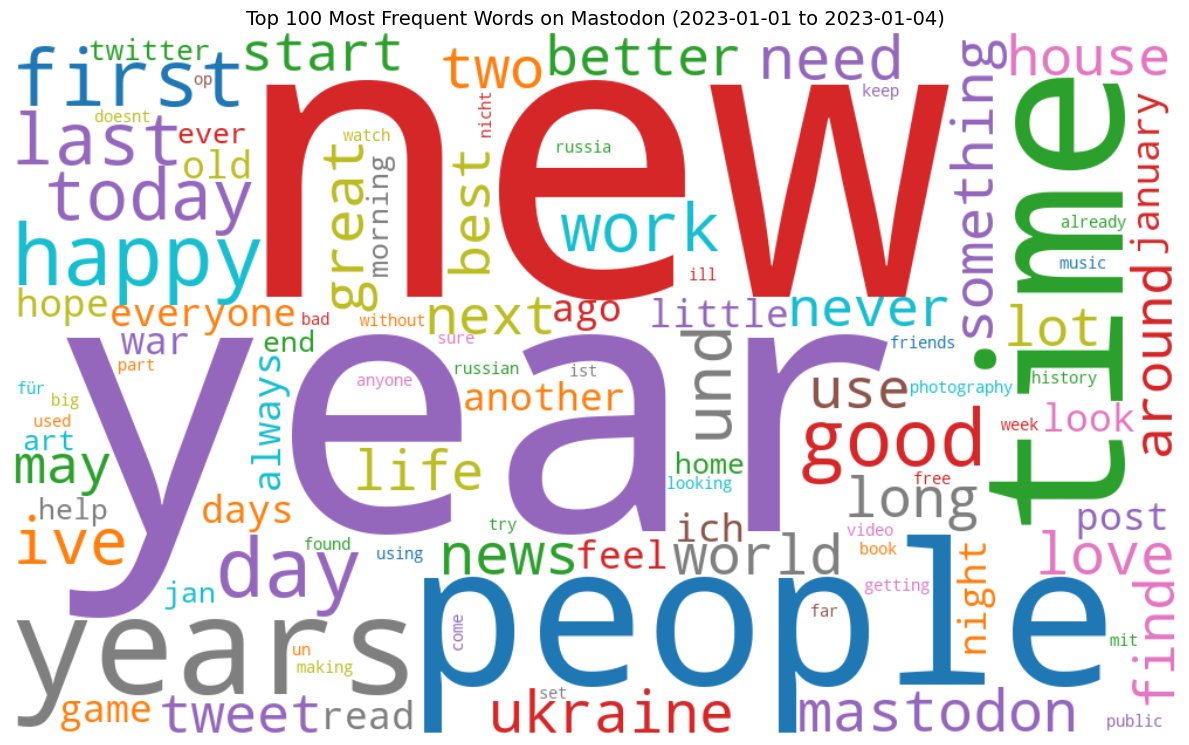

In [20]:
# === Generate and display word cloud ===
wordcloud = WordCloud(width=1000, height=600, background_color='white', colormap="tab10").generate_from_frequencies(keywords["keywords"])
period = f"{start_date} to {end_date}"

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title(f"Top 100 Most Frequent Words on Mastodon ({period})", fontsize=14)
plt.tight_layout()
plt.show()

## Number of posts every month from 2010 to 2025

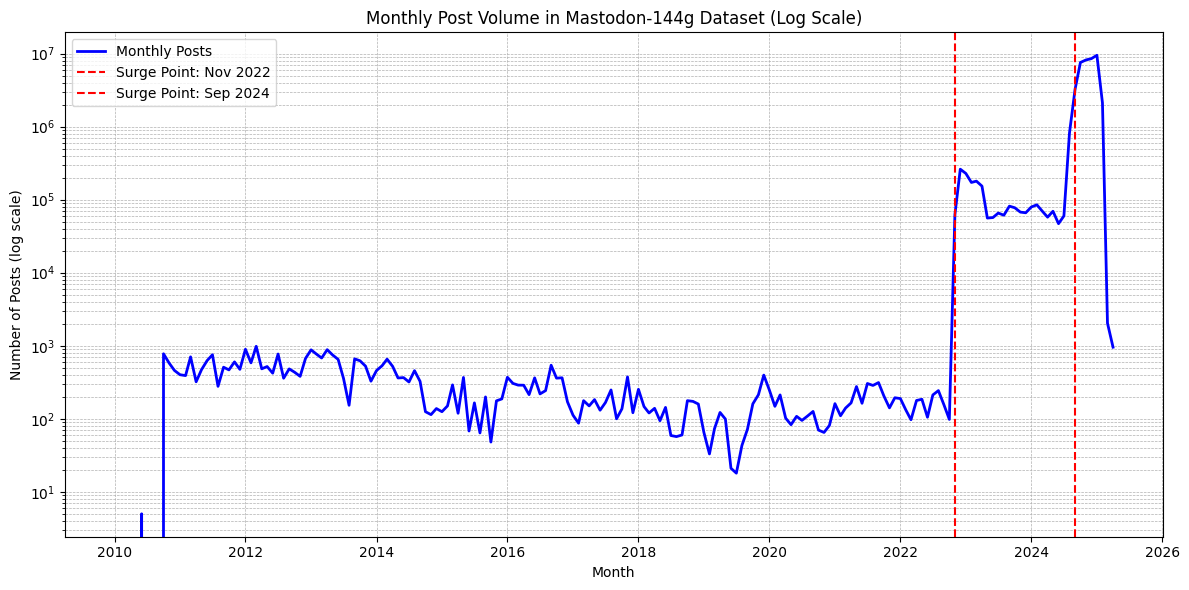

In [ ]:
# The monthly counts were calculated locally during preprocessing phase.
monthly_counts = {'2010-01': 0, '2010-02': 0, '2010-03': 0, '2010-04': 0, '2010-05': 0, '2010-06': 5, '2010-07': 0, '2010-08': 0, '2010-09': 0, '2010-10': 776, '2010-11': 581, '2010-12': 459, '2011-01': 401, '2011-02': 390, '2011-03': 704, '2011-04': 321, '2011-05': 470, '2011-06': 625, '2011-07': 753, '2011-08': 278, '2011-09': 508, '2011-10': 467, '2011-11': 601, '2011-12': 475, '2012-01': 895, '2012-02': 583, '2012-03': 982, '2012-04': 483, '2012-05': 519, '2012-06': 421, '2012-07': 770, '2012-08': 359, '2012-09': 482, '2012-10': 434, '2012-11': 381, '2012-12': 670, '2013-01': 878, '2013-02': 765, '2013-03': 679, '2013-04': 883, '2013-05': 748, '2013-06': 650, '2013-07': 357, '2013-08': 153, '2013-09': 661, '2013-10': 622, '2013-11': 525, '2013-12': 327, '2014-01': 457, '2014-02': 532, '2014-03': 655, '2014-04': 522, '2014-05': 362, '2014-06': 366, '2014-07': 319, '2014-08': 456, '2014-09': 325, '2014-10': 125, '2014-11': 114, '2014-12': 138, '2015-01': 125, '2015-02': 150, '2015-03': 291, '2015-04': 119, '2015-05': 368, '2015-06': 68, '2015-07': 165, '2015-08': 64, '2015-09': 199, '2015-10': 48, '2015-11': 176, '2015-12': 187, '2016-01': 370, '2016-02': 305, '2016-03': 289, '2016-04': 288, '2016-05': 214, '2016-06': 363, '2016-07': 219, '2016-08': 243, '2016-09': 541, '2016-10': 360, '2016-11': 364, '2016-12': 171, '2017-01': 112, '2017-02': 87, '2017-03': 177, '2017-04': 150, '2017-05': 183, '2017-06': 131, '2017-07': 167, '2017-08': 248, '2017-09': 100, '2017-10': 137, '2017-11': 374, '2017-12': 121, '2018-01': 253, '2018-02': 147, '2018-03': 120, '2018-04': 139, '2018-05': 94, '2018-06': 143, '2018-07': 59, '2018-08': 57, '2018-09': 60, '2018-10': 177, '2018-11': 173, '2018-12': 159, '2019-01': 65, '2019-02': 33, '2019-03': 73, '2019-04': 122, '2019-05': 99, '2019-06': 21, '2019-07': 18, '2019-08': 43, '2019-09': 72, '2019-10': 160, '2019-11': 213, '2019-12': 396, '2020-01': 248, '2020-02': 148, '2020-03': 212, '2020-04': 102, '2020-05': 83, '2020-06': 108, '2020-07': 95, '2020-08': 109, '2020-09': 126, '2020-10': 70, '2020-11': 65, '2020-12': 81, '2021-01': 161, '2021-02': 110, '2021-03': 140, '2021-04': 165, '2021-05': 276, '2021-06': 163, '2021-07': 304, '2021-08': 286, '2021-09': 313, '2021-10': 205, '2021-11': 141, '2021-12': 194, '2022-01': 189, '2022-02': 131, '2022-03': 97, '2022-04': 178, '2022-05': 185, '2022-06': 105, '2022-07': 212, '2022-08': 243, '2022-09': 155, '2022-10': 98, '2022-11': 62317, '2022-12': 261385, '2023-01': 228587, '2023-02': 172065, '2023-03': 179299, '2023-04': 153278, '2023-05': 56001, '2023-06': 56877, '2023-07': 65553, '2023-08': 61242, '2023-09': 81498, '2023-10': 77436, '2023-11': 67549, '2023-12': 66125, '2024-01': 79267, '2024-02': 85052, '2024-03': 70213, '2024-04': 57612, '2024-05': 69381, '2024-06': 46900, '2024-07': 59879, '2024-08': 816385, '2024-09': 3217638, '2024-10': 7551420, '2024-11': 8185855, '2024-12': 8522501, '2025-01': 9486428, '2025-02': 2115761, '2025-03': 2039, '2025-04': 955}
# Convert dictionary to DataFrame
df = pd.DataFrame(list(monthly_counts.items()), columns=['Month', 'Post Count'])
df['Month'] = pd.to_datetime(df['Month'])
df = df.sort_values('Month')

# Plotting with log scale and vertical marker
plt.figure(figsize=(12, 6))
plt.plot(df['Month'], df['Post Count'], color='blue', linewidth=2, label='Monthly Posts')
plt.axvline(pd.to_datetime('2022-11'), color='red', linestyle='--', label='Surge Point: Nov 2022')
plt.axvline(pd.to_datetime('2024-09'), color='red', linestyle='--', label='Surge Point: Sep 2024')

plt.yscale('log')
plt.title('Monthly Post Volume in Mastodon-144g Dataset (Log Scale)')
plt.xlabel('Month')
plt.ylabel('Number of Posts (log scale)')
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

## Input start_date, end_date and keyword (separated with "_") to see the average sentiment of relevant posts during the time interval.

In [ ]:
# This may take long if a long period is requested.
keyword = "crime_offence_victim_robbery_blackmail_murder_assault_harass_theft_fraud_violen"
start_date = "2024-08-19"
end_date = "2024-08-20"
senti = get_mastodon_keyword_sentiment(start_date, end_date, keyword)
print(senti)

{'avg_sentiment': -0.06090411688395976, 'count': 31, 'sum_sentiment': -1.8880276234027527}


# Average sentiment versus crime rate

In [ ]:
# DO NOT RUN THIS CELL UNLESS NECESSARY!!!
# !!! This cell takes quite long to run (25+ min) !!!
keyword = "crime_offence_victim_robbery_blackmail_murder_assault_harass_theft_fraud_violence"
start_year = 2010
end_year = 2024  # for financial year 2024–25
avg_sentiments = {}

for year in range(start_year, end_year + 1):
    fy_key = f"{year}-{year+1}"
    start_date = f"{year}-07-01"
    end_date = f"{year+1}-06-30"

    if fy_key == "2024-2025":
        print(f"Handling {fy_key} in monthly mode due to volume...")
        avg = get_monthly_avg(year)
        avg_sentiments[fy_key] = avg
        print(f"{fy_key}: {avg}")
        continue

    try:
        senti = get_mastodon_keyword_sentiment(start_date, end_date, keyword)
        if senti and 'avg_sentiment' in senti:
            avg = senti['avg_sentiment']
            print(f"{fy_key}: {avg:.4f}")
        else:
            avg = None
            print(f"No data returned for {fy_key}")
        avg_sentiments[fy_key] = avg

    except Exception as e:
        avg_sentiments[fy_key] = None

    time.sleep(1)


In [21]:
offender = get_offender_rate()
offender_dict = offender[0]
victim_raw = get_victim_rate()
# Offences to sum
target_offences = {
    "Homicide and related offences",
    "Sexual assault",
    "Kidnapping/abduction"
}

# Aggregate total victim rates per year
yearly_totals = {}
for entry in victim_raw:
    offence = entry.get("Offence")
    if offence in target_offences:
        for year, value in entry.items():
            if year != "Offence":
                yearly_totals[year] = yearly_totals.get(year, 0) + value

# Create DataFrame
victim = pd.DataFrame(sorted(yearly_totals.items()), columns=["Year", "Total Victimisation Rate"])

In [22]:
# Convert keys to "YYYY-YYYY" format
standardised_crime_data = {}

for k, v in offender_dict.items():
    if k == "Principal offence":
        continue
    parts = re.split(r"–|-", k)  # splits on en dash or hyphen
    if len(parts) == 2:
        start_year = "20" + parts[0][-2:]
        end_year = "20" + parts[1]
        std_key = f"{start_year}-{end_year}"
        standardised_crime_data[std_key] = v

# Generate full range of financial years from 2008-2009 to 2024-2025
full_years = [f"{year}-{year+1}" for year in range(2008, 2025)]

# Create full dataset
crime_rates = [standardised_crime_data.get(y, None) for y in full_years]
sentiments = [avg_sentiments.get(y, None) for y in full_years]


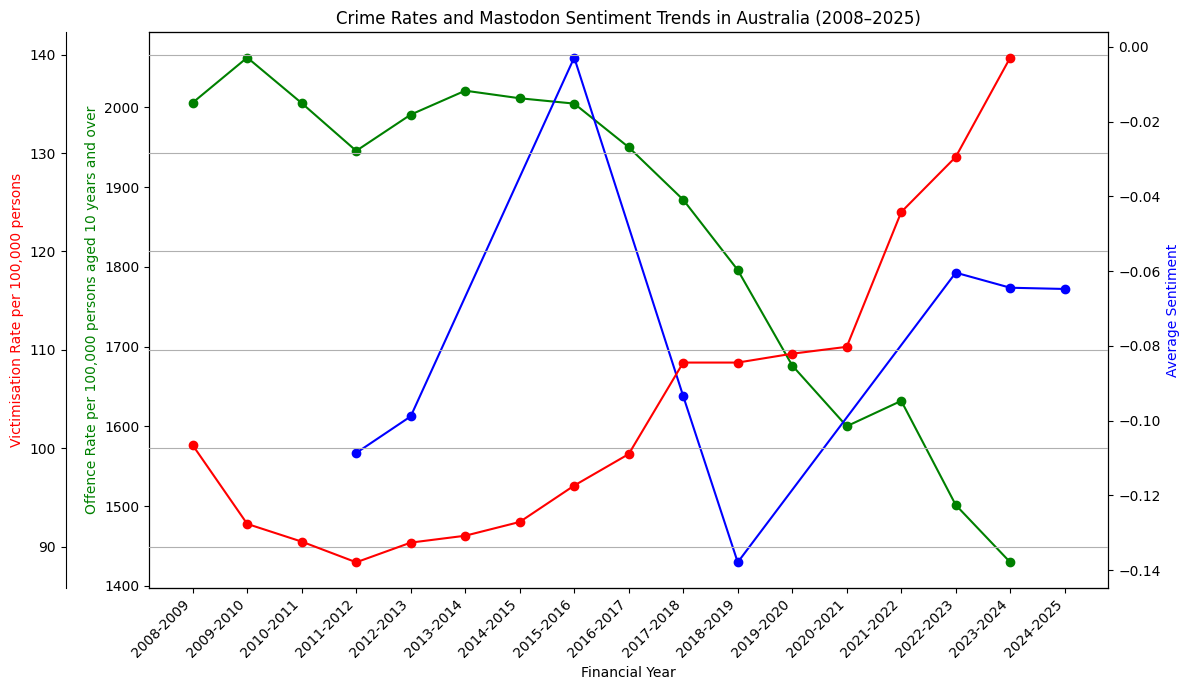

In [61]:
victim_overlay = []
victim["Year"] = victim["Year"].astype(int)
for fy in full_years:
    start_year = int(fy.split("-")[0])  # keep as int
    victim_val = victim.loc[victim["Year"] == start_year, "Total Victimisation Rate"]
    victim_overlay.append(victim_val.values[0] if not victim_val.empty else None)
    
# Create base figure and axes
fig, ax_crime = plt.subplots(figsize=(12, 7))
ax_sentiment = ax_crime.twinx()

# Crime Rate (left)
ax_crime.set_ylabel('Offence Rate per 100,000 persons aged 10 years and over', color='g')
ax_crime.plot(full_years, crime_rates, 'g-o', label='Crime Rate')

# Sentiment (right)
valid_idx = [i for i, v in enumerate(sentiments) if v is not None]
sent_years = [full_years[i] for i in valid_idx]
sent_vals  = [sentiments[i] for i in valid_idx]

ax_sentiment.plot(sent_years, sent_vals, 'b-o', label='Avg Sentiment')
ax_sentiment.set_ylabel('Average Sentiment', color='b')

# Victimisation Rate (outer-left)
ax_victim = ax_crime.twinx()
ax_victim.spines["left"].set_position(("outward", 60))
ax_victim.yaxis.set_label_position("left")
ax_victim.yaxis.set_ticks_position("left")
ax_victim.set_ylabel("Victimisation Rate per 100,000 persons", color='r')
ax_victim.plot(full_years, victim_overlay, 'r-o', label='Victimisation Rate')

# Hide duplicate spine
ax_victim.spines["right"].set_visible(False)

# X-axis
ax_crime.set_xlabel('Financial Year')
plt.xticks(rotation=45)
plt.title('Crime Rates and Mastodon Sentiment Trends in Australia (2008–2025)')
ax_crime.set_xticks(np.arange(len(full_years)))
ax_crime.set_xticklabels(full_years, rotation=45, ha='right')
plt.grid(True)
fig.tight_layout()
plt.show()

## Average sentiment versus dwelling statistic

In [ ]:
# DO NOT RUN THIS CELL UNLESS NECESSARY!!!
# !!! This cell takes quite long to run (~ 20 min) !!!
keyword = "housing_property_home_dwelling_price_cost_rent_mortgage_realestate_buy_sell_apartment_unit_house_market_affordability_bubble_loan_interest_investment_tenant_landlord"
start_year = 2010
end_year = 2024
months = [3, 6, 9, 12]

avg_sentiments = {}

for year in range(start_year, end_year + 1):
    for month in months:
        key = f"{year}-{month:02}"
        print(f"Processing {key}...")
        avg = get_quarterly_sentiment_robust(year, month, keyword)
        avg_sentiments[key] = avg
        print(f"{key}: {avg}")
        time.sleep(1)

In [27]:
house = get_dwelling()

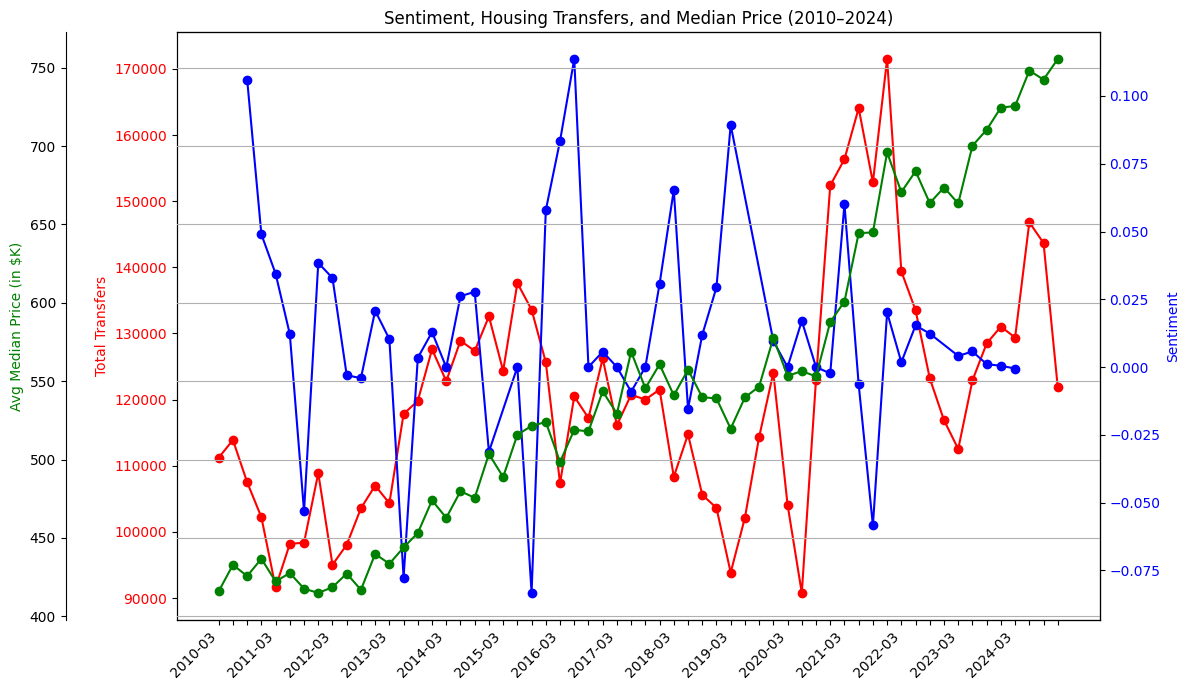

In [60]:
sent_years = [k for k, v in avg_sentiments.items() if v is not None]
sent_vals  = [v for v in avg_sentiments.values() if v is not None]

# Prepare Data
house['Quarter'] = house.apply(lambda row: f"{int(row['Year'])}-{int(row['Month']):02}", axis=1)
house['Avg_Median_Price'] = house[['Weighted_Median_Est_House', 'Weighted_Median_Att_Dwell']].mean(axis=1)
house['Total_Transfers'] = house['Total_Est_House_Transfers'] + house['Total_Att_Dwell_Transfers']
sentiment_df = pd.DataFrame(list(avg_sentiments.items()), columns=["Quarter", "Sentiment"])
merged = house.merge(sentiment_df, on="Quarter", how="left").sort_values("Quarter")

# Plot setup
fig, ax_transfer = plt.subplots(figsize=(12, 7))

ax_sentiment = ax_transfer.twinx()

# Plot total transfers (red, left)
ax_transfer.plot(merged['Quarter'], merged['Total_Transfers'], 'r-o', label='Total Transfers')
ax_transfer.set_ylabel("Total Transfers", color='r')
ax_transfer.tick_params(axis='y', labelcolor='r')

# Plot sentiment (blue, right)
ax_sentiment.plot(sent_years, sent_vals, 'b-o', label='Sentiment')
ax_sentiment.set_ylabel("Sentiment", color='b')
ax_sentiment.tick_params(axis='y', labelcolor='b')

# Plot median price (green, outer-left)
ax_price = ax_transfer.twinx()
ax_price.spines["left"].set_position(("outward", 80)) 
ax_price.yaxis.set_label_position("left")
ax_price.yaxis.set_ticks_position("left")
ax_price.set_ylabel("Avg Median Price (in $K)", color='g')
ax_price.plot(merged['Quarter'], merged['Avg_Median_Price'], 'g-o', label='Avg Median Price')

# X-axis cleanup: Only label March
quarter_labels = merged['Quarter']
march_labels = [label if label.endswith("-03") else "" for label in quarter_labels]
ax_transfer.set_xticks(range(len(quarter_labels)))

# Final touches
plt.title("Sentiment, Housing Transfers, and Median Price (2010–2024)")
ax_transfer.set_xticks(np.arange(len(merged['Quarter'])))
ax_transfer.set_xticklabels(march_labels, rotation=45, ha='right')
plt.grid(True)
fig.tight_layout()
plt.show()

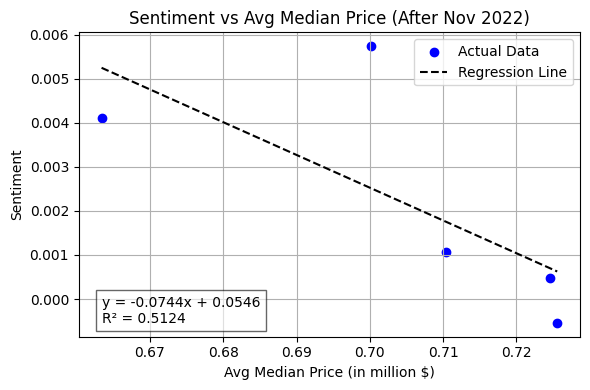

In [66]:
# Ensure 'Quarter' is datetime
merged['Quarter_dt'] = pd.to_datetime(merged['Quarter'], format="%Y-%m")

# Filter data after Nov 2022
filtered = merged[merged['Quarter_dt'] > "2022-11"]

# Drop rows with missing values
filtered = filtered.dropna(subset=['Sentiment', 'Avg_Median_Price'])

# Convert price to millions
X = (filtered[['Avg_Median_Price']] / 1000).values
y = filtered['Sentiment'].values

# Fit regression
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Plot
plt.figure(figsize=(6, 4))
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, y_pred, color='black', linestyle='--', label='Regression Line')
plt.xlabel("Avg Median Price (in million $)")
plt.ylabel("Sentiment")
plt.title("Sentiment vs Avg Median Price (After Nov 2022)")
plt.legend()
plt.grid(True)

# Output on plot
text = (
    f"y = {model.coef_[0]:.4f}x + {model.intercept_:.4f}\n"
    f"R² = {model.score(X, y):.4f}"
)
plt.text(x=X.min(), y=y.min(), s=text, fontsize=10, bbox=dict(facecolor='white', alpha=0.6))

plt.tight_layout()
plt.show()